<a href="https://colab.research.google.com/github/ChoonXiangg/dsp-project/blob/main/dsp_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Spectrograms: Birdsong

##Mount Google Drive

In [ ]:

import matplotlib.pyplot as plt


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Read the audio file, which in this case is stored on Google Drive.

In [ ]:
from scipy.io import wavfile
rate, audio = wavfile.read('/content/drive/MyDrive/dsp/dsp-project.wav')


/tmp/ipykernel_414/1530610331.py:2: WavFileWarning: Chunk (non-data) not understood, skipping it.
  rate, audio = wavfile.read('/content/drive/MyDrive/dsp/dsp-project.wav')


The wavfile.read function returns the audio samples themselves as well as the sampling rate in Hertz.

In [ ]:
print('Audio sampling rate:', rate, 'Hz')

Audio sampling rate: 44100 Hz


##Calculate Audio Length

In [ ]:
N = audio.shape[0]    # Number of audio samples
L = N / rate          # Length of audio in seconds
print(f'Audio length: {L:.2f} s')

Audio length: 17.39 s


## Stereo or Mono Audio?

In [ ]:
# If audio is in stereo, compute the mean of the two channels
#audio = np.mean(audio, axis=1)

##Play Audio

ipython.display is a module in IPython/Jupyter that provides tools for displaying rich output in notebooks, including audio and images.

In [ ]:
import IPython.display as ipd

ipd.Audio(audio, rate=rate)

##Compute Spectrogram

Many libraries that provide spectrogram functions in Python. Here, we'll use the Scientific Python library, SciPy (https://scipy.org/about/). Note all the parameters that may be set - for now there are some good default values.

In [ ]:
import numpy as np
from scipy import signal
# Spectrogram calculation using scipy
f, t, spec = signal.spectrogram(audio,
                                fs=rate,
                                window=('hann'),
                                nperseg=1024,
                                noverlap=1024-100,
                                detrend=False,
                                scaling='spectrum'
                                )



Now calculate the magnitude of the spectrum in Decibels, dB.

In [ ]:
# Calculate the magnitude of the spectrum in decibels
spec_db = 10*np.log10(spec)

##Plot Audio: Time-Domain and Spectrogram

Two helper functions to perform the plotting are defined.

In [ ]:
from matplotlib._api import caching_module_getattr
def plot_time_domain():
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111)
    ax.plot(np.arange(N) / rate, audio, color='steelblue')
    ax.set_title('Birdsong', fontsize=16, pad=10, color='sienna');
    ax.set_xlabel('Time (s)', fontsize=14, labelpad=10)
    ax.set_ylabel('Amplitude', fontsize=14, labelpad=10);
    ax.tick_params(axis='both', which='both', labelsize=10, length=0)

In [ ]:
def plot_spec_scipy():
    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.pcolormesh(t, f/1000, spec_db, vmax=spec_db.max(), vmin=15, cmap=plt.cm.Oranges, linewidth=10, shading='auto')
    cb = fig.colorbar(im, ax=ax, orientation="horizontal")
    ax.set_title('Birdsong Spectrogram', fontsize=16, pad=10, color='sienna');
    ax.set_xlabel('Time (s)', fontsize=14, labelpad=10);
    ax.set_ylabel('Frequency (kHz)', fontsize=14, labelpad=10)
    ax.tick_params(axis='both', which='both', labelsize=10, length=0)
    ax.set_ylim(0, 16)
    ax.set_xlim(0, 8)
    cb.set_label('Power (dB)', fontsize=14, labelpad=10)
    cb.ax.tick_params(labelsize=10)

Call the plotting functions to plot.

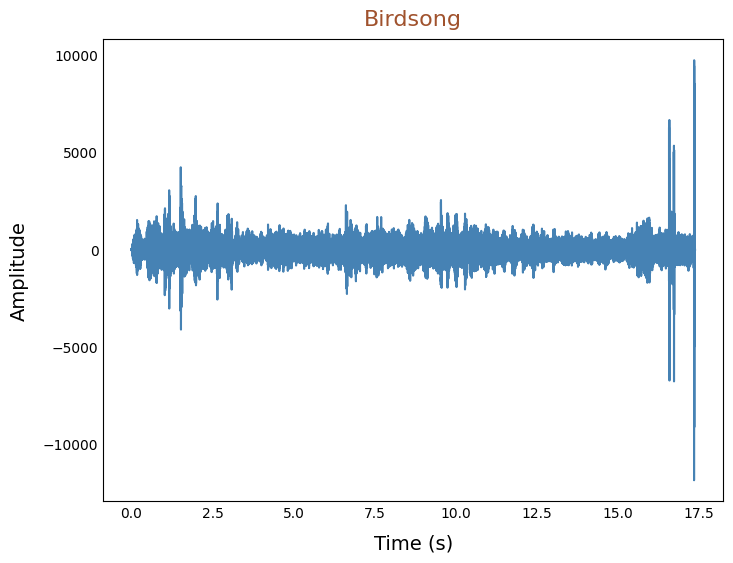

In [ ]:
plot_time_domain();

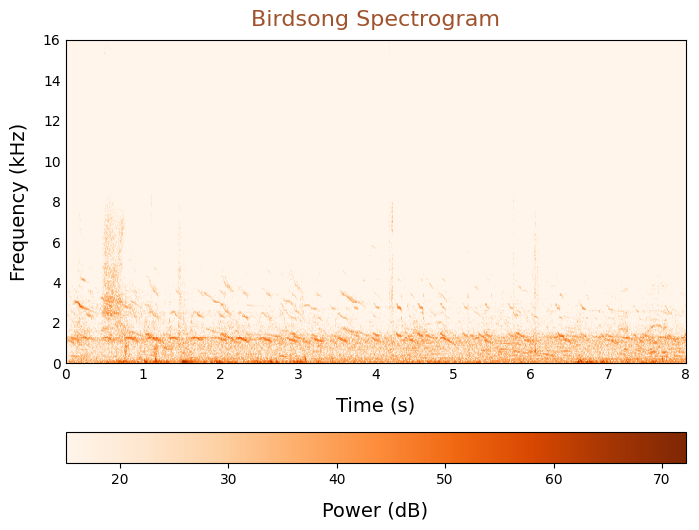

In [ ]:
plot_spec_scipy();

##Analysis

\- What technical information can you glean from these plots?

\- What will the audio sound like?

\- What information about the environment that the audio was recorded in can you glean?

##References

Idea

Use API that recognises birds from audio